<a href="https://colab.research.google.com/github/tomasroel/dmeyf2026/blob/main/ensembles/z4942_tareahogar_04_Trabajado_TR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea para el Hogar 04

##  1. Big Picture

LightGBM es el algoritmo estado del arte para datasets estructurados.
<br> La Bayesian Optimization es el estado del arte para optimización de hiperparámetros
<br> Las soluciones a las tres competencias de la asignatura contendrán LightGBMs y Bayesian Optimizations
<br> LightGBM ha aumentado en forma no darwiniana sus hiperparámetros en los últimos ocho años; no todos los existentes son útiles.
<br> Es necesario lograr entender cuales son los hiperparámetros relevantes de LightGBM

## 2. Hiperparámetros del LightGBM

Los objetivos de esta tarea son:


*   Aumentar la rentabilidad de la campaña de marketing de retención proactiva de clientes.
*   Generar un mejor modelo optimizando sus hiperparámetros
*   Conceptual : investigar los mas relevantes hiperparámetros de LightGBM
*   Familiarizarse con la Bayesian Optimization, sus largos tiempos de corrida y opciones para reducirlos
*   Familiarizarse con el uso de máquinas virtuales de Google Colab
*   Ver un pipeline completo de optimización de hiperparámetros y puesta en producción

LightGBM cuenta con mas de 60 hiperparámetros, siendo posible utilizar 40 al mismo tiempo, aunque no razonable.
<br> La documentación oficial de los hiperparámetros de LightGBM es  https://lightgbm.readthedocs.io/en/latest/Parameters.html#core-parameters


Se lo alerta sobre que una Optimizacion Bayesiana lleva varias horas de corrida, y usted deberá correr VARIAS optimizaciones para descubrir cuales parámetros conviene optimizar.
<br> A pesar que la próxima clase es recien en viernes 01 de agosto, inicie la tarea con tiempo, aprenda a planificar estratégicamente sus corridas como un@ científ@  de datos.

Es necesario investigar cuales son los hiperparámetros de LightGBM que vale la pena optimizar en una Bayesian Optimization, ya que los realmente utiles son apenas un reducido subconjunto.
<br>Usted deberá investigar cuales son los hiperparámetros mas relevantes de LightGBM, su primer alternativa es preguntándole a su amigo con capacidades especiales ChatGPT o sus endogámicos familiares Claude, DeepSeek, Gemini, Grok, etc
<br> La segunda alternativa es la propia documentación de LightGBM  https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html


Adicionalmente podra buscar información como la que proveen esta diminuta muestra aleatoria de artículos ligeros:
*  https://medium.com/@sarahzouinina/a-deep-dive-into-lightgbm-how-to-choose-and-tune-parameters-7c584945842e
*  https://www.kaggle.com/code/somang1418/tuning-hyperparameters-under-10-minutes-lgbm
*  https://towardsdatascience.com/beginners-guide-to-the-must-know-lightgbm-hyperparameters-a0005a812702/


<br>  La muestra anterior se brinda a modo de ejemplo, usted deberá buscar muuuuchas  fuentes adicionales de información
<br> Tenga presente que LightGBM es el estado del arte en modelado predictivo para datasets estructurado, que son el 90% del trabajo del 95% de los Data Scientists en Argentina.

El desafío de esta tarea es:
* Qué hiperparparámetros conviene optimizar?  Las recomendaciones de los artículos ligeros es siempre sensata?  Sus autores realmente hicieron experimentos o son siemplemente escritores de entretenimiento carente de base científica?
* Elegidos los hiperparámetros, cual es el  <desde, hasta> que se debe utilizar en la Bayesian Optimization ?
* Realmente vale la pena optimizar 10 o 16 hiperparámetros al mismo tiempo ?  No resulta contraproducente una búsqueda en un espacio de tal alta dimensionalidad ?

### Estrategia de Exploración

Se utilizará la siguiente estrategia de optimización:

En primer lugar, se dejarán fijos los siguientes parámetros:

*   `max_depth = -1` — el crecimiento del árbol ya lo controla `num_leaves`
*   `boosting = "gbdt"`
*    `objective = "binary"`
*    `min_sum_hessian_in_leaf` — bajarlo a ~0.001, si no bloquea hojas chicas junto con el desbalance



En la segunda corrida, se irá por la optimización de todos los parámetros de 'capacidad del modelo' en conjunto.



*   num_leaves
*   min_data_in_leaf
*   learning_rate
*   feature_fraction
*   lambda_l1
*   lambda_l2
*   min_gain_to_split



## 2.1  Seteo del ambiente en Google Colab

Esta parte se debe correr con el runtime en Python3
<br>Ir al menu, Runtime -> Change Runtime Type -> Runtime type ->  **Python 3**

Conectar la virtual machine donde esta corriendo Google Colab con el  Google Drive, para poder tener persistencia de archivos

In [1]:
# primero establecer el Runtime de Python 3
from google.colab import drive
drive.mount('/content/.drive')

Mounted at /content/.drive


Para correr la siguiente celda es fundamental en Arranque en Frio haber copiado el archivo kaggle.json al Google Drive, en la carpeta indicada en el instructivo

<br>los siguientes comando estan en shell script de Linux
*   Crear las carpetas en el Google Drive
*   "instalar" el archivo kaggle.json desde el Google Drive a la virtual machine para que pueda ser utilizado por la libreria  kaggle de Python
*   Bajar el  **dataset_pequeno**  al  Google Drive  y tambien al disco local de la virtual machine que esta corriendo Google Colab



In [2]:
%%shell

mkdir -p "/content/.drive/My Drive/dmeyf"
mkdir -p "/content/buckets"
ln -s "/content/.drive/My Drive/dmeyf" /content/buckets/b1


mkdir -p /content/buckets/b1/exp
mkdir -p /content/buckets/b1/datasets
mkdir -p /content/datasets



archivo_origen="https://storage.googleapis.com/open-courses/dmeyf2026-9c6f/competencia_01_crudo.csv"
archivo_destino="/content/datasets/competencia_01_crudo.csv"
archivo_destino_bucket="/content/buckets/b1/datasets/competencia_01_crudo.csv"

if ! test -f $archivo_destino_bucket; then
  wget  $archivo_origen  -O $archivo_destino_bucket
fi


if ! test -f $archivo_destino; then
  cp  $archivo_destino_bucket  $archivo_destino
fi


## Generacion de la clase_ternaria

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Tipe -> Runtime type -> R

In [1]:
require( "data.table" )

# leo el dataset
dataset <- fread("/content/datasets/competencia_01_crudo.csv" )

# calculo el periodo0 consecutivo
dsimple <- dataset[, list(
    "pos" = .I,
    numero_de_cliente,
    periodo0 = as.integer(foto_mes/100)*12 +  foto_mes%%100 ) ]


# ordeno
setorder( dsimple, numero_de_cliente, periodo0 )

# calculo topes
periodo_ultimo <- dsimple[, max(periodo0) ]
periodo_anteultimo <- periodo_ultimo - 1


# calculo los leads de orden 1 y 2
dsimple[, c("periodo1", "periodo2") :=
    shift(periodo0, n=1:2, fill=NA, type="lead"),  numero_de_cliente ]

# assign most common class values = "CONTINUA"
dsimple[ periodo0 < periodo_anteultimo, clase_ternaria := "CONTINUA" ]

# calculo BAJA+1
dsimple[ periodo0 < periodo_ultimo &
    ( is.na(periodo1) | periodo0 + 1 < periodo1 ),
    clase_ternaria := "BAJA+1" ]

# calculo BAJA+2
dsimple[ periodo0 < periodo_anteultimo & (periodo0+1 == periodo1 )
    & ( is.na(periodo2) | periodo0 + 2 < periodo2 ),
    clase_ternaria := "BAJA+2" ]


# pego el resultado en el dataset original y grabo
setorder( dsimple, pos )
dataset[, clase_ternaria := dsimple$clase_ternaria ]

fwrite( dataset,
    file =  "/content/datasets/competencia_01.csv.gz",
    sep = ","
)

Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%




In [2]:
setorder( dataset, foto_mes, clase_ternaria, numero_de_cliente)
dataset[, .N, list(foto_mes, clase_ternaria)]

foto_mes,clase_ternaria,N
<int>,<chr>,<int>
202103,BAJA+1,1019
202103,BAJA+2,960
202103,CONTINUA,160921
202104,BAJA+1,964
202104,BAJA+2,1139
202104,CONTINUA,161181
202105,BAJA+1,1143
202105,BAJA+2,870
202105,CONTINUA,161755


## 2.2 Optimizacion Hiperparámetros

Esta parte se debe correr con el runtime en lenguaje R Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

### 2.2.1 Inicio

limpio el ambiente de R

In [3]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Wed Sep 09 01:57:35 PM 2026"

In [4]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,741417,39.6,1473300,78.7,1473300,78.7
Vcells,1391394,10.7,170859661,1303.6,212615883,1622.2


### 2.2.2 Carga de Librerias

Esta parte lleva varios minutos la primera vez en Google Colab

In [5]:
# cargo las librerias que necesito
require("data.table")
require("parallel")

if(!require("R.utils")) install.packages("R.utils")
require("R.utils")

if( !require("primes") ) install.packages("primes")
require("primes")

if( !require("utils") ) install.packages("utils")
require("utils")

if( !require("rlist") ) install.packages("rlist")
require("rlist")

if( !require("yaml")) install.packages("yaml")
require("yaml")

if( !require("lightgbm") ) install.packages("lightgbm")
require("lightgbm")

if( !require("DiceKriging") ) install.packages("DiceKriging")
require("DiceKriging")

if( !require("mlrMBO") ) install.packages("mlrMBO")
require("mlrMBO")

Loading required package: parallel

Loading required package: R.utils

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘R.utils’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘R.oo’, ‘R.methodsS3’


Loading required package: R.utils

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


At

### 2.2.3 Definicion de Parametros

aqui debe cargar SU semilla primigenia
<br>recuerde cambiar el numero de experimento en cada corrida nueva

In [31]:
PARAM <- list()
PARAM$experimento <- 4942
PARAM$semilla_primigenia <- 911341


In [32]:
# training y future
PARAM$train <- c(202104)
PARAM$train_final <- c(202104)
PARAM$future <- c(202106)
PARAM$semilla_kaggle <- 314159
PARAM$cortes <- seq(4000, 19000, by= 500)

In [33]:
# un undersampling de 0.1  toma solo el 10% de los CONTINUA
# undersampling de 1.0  implica tomar TODOS los datos

PARAM$trainingstrategy$undersampling <- 0.1

In [34]:
# Parametros LightGBM

PARAM$hyperparametertuning$xval_folds <- 10

# parametros fijos del LightGBM que se pisaran con la parte variable de la BO
PARAM$lgbm$param_fijos <-  list(
  boosting= "gbdt", # puede ir  dart  , ni pruebe random_forest
  objective= "binary",
  metric= "auc",
  first_metric_only= FALSE,
  boost_from_average= TRUE,
  feature_pre_filter= FALSE,
  force_row_wise= TRUE, # para reducir warnings
  verbosity= -100,

  seed= PARAM$semilla_primigenia,

  max_depth= -1L, # -1 significa no limitar,  por ahora lo dejo fijo
  min_gain_to_split= 0, # min_gain_to_split >= 0
  min_sum_hessian_in_leaf= 0.001, #  min_sum_hessian_in_leaf >= 0.0
  lambda_l1= 0.0, # lambda_l1 >= 0.0
  lambda_l2= 0.0, # lambda_l2 >= 0.0
  max_bin= 31L, # lo debo dejar fijo, no participa de la BO

  bagging_fraction= 1.0, # 0.0 < bagging_fraction <= 1.0
  pos_bagging_fraction= 1.0, # 0.0 < pos_bagging_fraction <= 1.0
  neg_bagging_fraction= 1.0, # 0.0 < neg_bagging_fraction <= 1.0
  is_unbalance= FALSE, #
  scale_pos_weight= 1.0, # scale_pos_weight > 0.0

  drop_rate= 0.1, # 0.0 < neg_bagging_fraction <= 1.0
  max_drop= 50, # <=0 means no limit
  skip_drop= 0.5, # 0.0 <= skip_drop <= 1.0

  extra_trees= FALSE,

  early_stopping_rounds= 200L,   # Early Stopping. Nuevo, agregado. Frena el algoritmo si pasan 200 rondas sin mejorar el AUC
  num_iterations= 4096L,         # <- funciona como techo. No siempre se hacen esta cantidad de iteraciones.
  learning_rate= 0.02,
  feature_fraction= 0.5,
  num_leaves= 750,
  min_data_in_leaf= 5000
)


Aqui se definen los hiperparámetros de LightGBM que participan de la Bayesian Optimization
<br> si es un numero entero debe ir  makeIntegerParam
<br> si es un numero real (con decimales) debe ir  makeNumericParam
<br> es muy importante leer cuales son un lower y upper  permitidos y ademas razonables

In [35]:
# Aqui se cargan los bordes de los hiperparametros de la BO
PARAM$hypeparametertuning$hs <- makeParamSet(
  # los 4 de la primera corrida, mismos rangos
  makeNumericParam("learning_rate",     lower= 0.01, upper= 0.05),
  makeNumericParam("feature_fraction",  lower= 0.3,  upper= 0.9),
  makeIntegerParam("num_leaves",        lower= 15L,   upper= 300L),
  makeIntegerParam("min_data_in_leaf",  lower= 100L,   upper= 2000L),

  # los 3 nuevos, en escala logaritmica
  makeNumericParam("lambda_l1",         lower= -3, upper= 0,
                   trafo= function(x) ifelse(x <= -2.9, 0, 10^x)),
  makeNumericParam("lambda_l2",         lower= -3, upper= 1,
                   trafo= function(x) ifelse(x <= -2.9, 0, 10^x)),
  makeNumericParam("min_gain_to_split", lower= -3, upper= 0,
                   trafo= function(x) ifelse(x <= -2.9, 0, 10^x))
)

A mayor cantidad de hiperparámetros, se debe aumentar las iteraciones de la Bayesian Optimization
<br> 30 es un valor muy tacaño, pero corre rápido
<br> deberia partir de 50, alcanzando los 100 si se dispone de tiempo

In [36]:
PARAM$hyperparametertuning$iteraciones <- 60 # iteraciones bayesianas

In [37]:
# particionar agrega una columna llamada fold a un dataset
#   que consiste en una particion estratificada segun agrupa
# particionar( data=dataset, division=c(70,30),
#  agrupa=clase_ternaria, seed=semilla)   crea una particion 70, 30

particionar <- function(data, division, agrupa= "", campo= "fold", start= 1, seed= NA) {
  if (!is.na(seed)) set.seed(seed, "L'Ecuyer-CMRG")

  bloque <- unlist(mapply(
    function(x, y) {rep(y, x)},division, seq(from= start, length.out= length(division))))

  data[, (campo) := sample(rep(bloque,ceiling(.N / length(bloque))))[1:.N],by= agrupa]
}

In [38]:
# iniciliazo el dataset de realidad, para medir ganancia
realidad_inicializar <- function( pfuture, pparam) {

  # datos para verificar la ganancia
  drealidad <- pfuture[, list(numero_de_cliente, foto_mes, clase_ternaria)]

  particionar(drealidad,
    division= c(3, 7),
    agrupa= "clase_ternaria",
    seed= PARAM$semilla_kaggle
  )

  return( drealidad )
}

In [39]:
# evaluo ganancia en los datos de la realidad

realidad_evaluar <- function( prealidad, pprediccion) {

  prealidad[ pprediccion,
    on= c("numero_de_cliente", "foto_mes"),
    predicted:= i.Predicted
  ]

  tbl <- prealidad[, list("qty"=.N), list(fold, predicted, clase_ternaria)]

  res <- list()
  res$public  <- tbl[fold==1 & predicted==1L, sum(qty*ifelse(clase_ternaria=="BAJA+2", 1072500, -27500))]/0.3
  res$private <- tbl[fold==2 & predicted==1L, sum(qty*ifelse(clase_ternaria=="BAJA+2", 1072500, -27500))]/0.7
  res$total <- tbl[predicted==1L, sum(qty*ifelse(clase_ternaria=="BAJA+2", 1072500, -27500))]

  prealidad[, predicted:=NULL]
  return( res )
}

### 2.2.4  Preprocesamiento

In [40]:
# carpeta de trabajo

setwd("/content/buckets/b1/exp")
experimento_folder <- paste0("HT", PARAM$experimento)
dir.create(experimento_folder, showWarnings=FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento_folder ))

In [41]:
# lectura del dataset
dataset <- fread("/content/datasets/competencia_01.csv.gz", stringsAsFactors= TRUE)

In [42]:
dataset_train <- dataset[foto_mes %in% PARAM$train]

In [43]:
# paso la clase a binaria que tome valores {0,1}  enteros
#  BAJA+1 y BAJA+2  son  1,   CONTINUA es 0
#  a partir de ahora ya NO puedo cortar  por prob(BAJA+2) > 1/40

dataset_train[,
  clase01 := ifelse(clase_ternaria %in% c("BAJA+2","BAJA+1"), 1L, 0L)
]

In [44]:
# defino los datos que forma parte del training
# aqui se hace el undersampling de los CONTINUA
# notar que para esto utilizo la SEGUNDA semilla

set.seed(PARAM$semilla_primigenia, kind = "L'Ecuyer-CMRG")
dataset_train[, azar := runif(nrow(dataset_train))]
dataset_train[, training := 0L]

dataset_train[
  foto_mes %in%  PARAM$train &
    (azar <= PARAM$trainingstrategy$undersampling | clase_ternaria %in% c("BAJA+1", "BAJA+2")),
  training := 1L
]

In [45]:
# los campos que se van a utilizar

campos_buenos <- setdiff(
  colnames(dataset_train),
  c("clase_ternaria", "clase01", "azar", "training")
)

In [46]:
# dejo los datos en el formato que necesita LightGBM

dtrain <- lgb.Dataset(
  data= data.matrix(dataset_train[training == 1L, campos_buenos, with= FALSE]),
  label= dataset_train[training == 1L, clase01],
  free_raw_data= FALSE
)

nrow(dtrain)
ncol(dtrain)

[1] 18252

[1] 154

### 2.2.5 Configuracion Bayesian Optimization

Cambio y ajuste en esta función. Capturo el num_iterations de mejor score.

In [47]:
# En el argumento x llegan los parmaetros de la bayesiana
#  devuelve la AUC en cross validation del modelo entrenado

EstimarGanancia_AUC_lightgbm <- function(x) {

  param_completo <- modifyList(PARAM$lgbm$param_fijos, x)

  modelocv <- lgb.cv(
    data= dtrain,
    nfold= PARAM$hyperparametertuning$xval_folds,
    stratified= TRUE,
    param= param_completo
  )

  AUC <- modelocv$best_score

  # cantidad de arboles que el early stopping encontro optima
  iteracion_optima <- modelocv$best_iter        # <-- AGREGAR

  rm(modelocv)
  gc(full= TRUE, verbose= FALSE)

  message(format(Sys.time(), "%a %b %d %X %Y"),
          " AUC ", AUC, "  iter ", iteracion_optima)

  # mlrMBO guarda esto como columna extra en el opt.path
  attr(AUC, "extras") <- list(num_iterations= iteracion_optima)   # <-- AGREGAR

  return(AUC)
}

In [48]:
# Aqui comienza la configuracion de la Bayesian Optimization

# en este archivo quedan la evolucion binaria de la BO
kbayesiana <- "bayesiana.RDATA"

funcion_optimizar <- EstimarGanancia_AUC_lightgbm # la funcion que voy a maximizar

configureMlr(show.learner.output= FALSE)

# configuro la busqueda bayesiana,  los hiperparametros que se van a optimizar
# por favor, no desesperarse por lo complejo

obj.fun <- makeSingleObjectiveFunction(
  fn= funcion_optimizar, # la funcion que voy a maximizar
  minimize= FALSE, # estoy Maximizando la ganancia
  noisy= TRUE,
  par.set= PARAM$hypeparametertuning$hs, # definido al comienzo del programa
  has.simple.signature= FALSE # paso los parametros en una lista
)

# cada 600 segundos guardo el resultado intermedio
ctrl <- makeMBOControl(
  save.on.disk.at.time= 600, # se graba cada 600 segundos
  save.file.path= kbayesiana
) # se graba cada 600 segundos

# indico la cantidad de iteraciones que va a tener la Bayesian Optimization
ctrl <- setMBOControlTermination(
  ctrl,
  iters= PARAM$hyperparametertuning$iteraciones
) # cantidad de iteraciones

# defino el método estandar para la creacion de los puntos iniciales,
# los "No Inteligentes"
ctrl <- setMBOControlInfill(ctrl, crit= makeMBOInfillCritEI())

# establezco la funcion que busca el maximo
surr.km <- makeLearner(
  "regr.km",
  predict.type= "se",
  covtype= "matern3_2",
  control= list(trace= TRUE)
)


### 2.2.6 Corrida Bayesian Optimization

In [49]:

# inicio la optimizacion bayesiana, retomando si ya existe
# es la celda mas lenta de todo el notebook

if (!file.exists(kbayesiana)) {
  bayesiana_salida <- mbo(obj.fun, learner= surr.km, control= ctrl)
} else {
  bayesiana_salida <- mboContinue(kbayesiana) # retomo en caso que ya exista
}

Computing y column(s) for design. Not provided.

Wed Sep 09 02:20:44 PM 2026 AUC 0.92006123646182  iter 618

Wed Sep 09 02:22:26 PM 2026 AUC 0.92332241792919  iter 634

Wed Sep 09 02:23:07 PM 2026 AUC 0.92172792717968  iter 365

Wed Sep 09 02:24:18 PM 2026 AUC 0.922846074574713  iter 301

Wed Sep 09 02:25:03 PM 2026 AUC 0.922518072961177  iter 378

Wed Sep 09 02:26:01 PM 2026 AUC 0.923374950150947  iter 246

Wed Sep 09 02:26:50 PM 2026 AUC 0.924025329379019  iter 269

Wed Sep 09 02:28:05 PM 2026 AUC 0.922502364232174  iter 449

Wed Sep 09 02:28:41 PM 2026 AUC 0.924415816609542  iter 169

Wed Sep 09 02:30:25 PM 2026 AUC 0.92238843457557  iter 742

Wed Sep 09 02:32:08 PM 2026 AUC 0.920156619494236  iter 795

Wed Sep 09 02:33:24 PM 2026 AUC 0.918319209339568  iter 770

Wed Sep 09 02:34:46 PM 2026 AUC 0.926420704108284  iter 390

Wed Sep 09 02:36:12 PM 2026 AUC 0.925334004374855  iter 437

Wed Sep 09 02:37:23 PM 2026 AUC 0.919941717132279  iter 446

Wed Sep 09 02:38:04 PM 2026 AUC 0.925575

In [50]:

tb_bayesiana <- as.data.table(bayesiana_salida$opt.path)
colnames( tb_bayesiana)

[1] "learning_rate"     "feature_fraction"  "num_leaves"       
 [4] "min_data_in_leaf"  "lambda_l1"         "lambda_l2"        
 [7] "min_gain_to_split" "y"                 "dob"              
[10] "eol"               "error.message"     "exec.time"        
[13] "ei"                "error.model"       "train.time"       
[16] "prop.type"         "propose.time"      "se"               
[19] "mean"              "num_iterations"

In [51]:
# almaceno los resultados de la Bayesian Optimization
# y capturo los mejores hiperparametros encontrados

tb_bayesiana <- as.data.table(bayesiana_salida$opt.path)

tb_bayesiana[, iter := .I]

# ordeno en forma descendente por AUC = y
setorder(tb_bayesiana, -y)

# grabo para eventualmente poder utilizarlos en OTRA corrida
fwrite( tb_bayesiana,
  file= "BO_log.txt",
  sep= "\t"
)

# los mejores hiperparámetros son los que quedaron en el registro 1 de la tabla
PARAM$out$lgbm$mejores_hiperparametros <- tb_bayesiana[
  1, # el primero es el de mejor AUC
  setdiff(colnames(tb_bayesiana),
    c("y","dob","eol","error.message","exec.time","ei","error.model",
      "train.time","prop.type","propose.time","se","mean","iter")),
  with= FALSE
]


PARAM$out$lgbm$y <- tb_bayesiana[1, y]


In [52]:
# mlrMBO guarda los valores SIN transformar en el opt.path
# aplico la trafo a mano

destrafo <- function(x) ifelse(x <= -2.9, 0, 10^x)

for (hp in c("lambda_l1", "lambda_l2", "min_gain_to_split")) {
  PARAM$out$lgbm$mejores_hiperparametros[[hp]] <-
    destrafo(PARAM$out$lgbm$mejores_hiperparametros[[hp]])
}

print(PARAM$out$lgbm$mejores_hiperparametros)

   learning_rate feature_fraction num_leaves min_data_in_leaf lambda_l1
           <num>            <num>      <int>            <int>     <num>
1:    0.01006608        0.4375745        137              251 0.9900798
   lambda_l2 min_gain_to_split num_iterations
       <num>             <num>          <int>
1:  2.427845       0.002795127            775


In [53]:
write_yaml( PARAM, file="PARAM.yml")

In [54]:
print(PARAM$out$lgbm$mejores_hiperparametros)
print(PARAM$out$lgbm$y)

   learning_rate feature_fraction num_leaves min_data_in_leaf lambda_l1
           <num>            <num>      <int>            <int>     <num>
1:    0.01006608        0.4375745        137              251 0.9900798
   lambda_l2 min_gain_to_split num_iterations
       <num>             <num>          <int>
1:  2.427845       0.002795127            775
[1] 0.9272157


In [55]:
tb_bayesiana

learning_rate,feature_fraction,num_leaves,min_data_in_leaf,lambda_l1,lambda_l2,min_gain_to_split,y,dob,eol,⋯,exec.time,ei,error.model,train.time,prop.type,propose.time,se,mean,num_iterations,iter
<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,⋯,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.01006608,0.4375745,137,251,-0.004329799,0.3852210,-2.5535984556,0.9272157,49,NA,⋯,145.920,-1.365956e-04,NA,0.208,infill_ei,0.616,0.0003967483,0.9269887,775,77
0.02638493,0.4981698,258,166,-1.046576273,0.9966560,-0.9178392629,0.9272117,60,NA,⋯,80.474,-1.382397e-04,NA,0.403,infill_ei,1.040,0.0009667652,0.9265394,310,88
0.02481207,0.4625686,240,252,-0.169630395,-0.7155283,-2.8887718942,0.9270342,6,NA,⋯,76.898,-2.653907e-04,NA,0.172,infill_ei,0.566,0.0004138604,0.9270271,283,34
0.04716470,0.5364349,157,218,-2.975730915,-2.9991138,-0.0006069343,0.9269983,30,NA,⋯,41.019,-6.145435e-05,NA,0.262,infill_ei,0.614,0.0009568880,0.9259497,141,58
0.01447019,0.4903715,160,244,-0.157921011,-0.2887681,-2.9999479570,0.9268980,13,NA,⋯,114.886,-1.271483e-04,NA,0.190,infill_ei,0.569,0.0002834685,0.9270612,476,41
0.01149684,0.3725016,16,284,-0.045369047,0.6913288,-2.3397203462,0.9268656,56,NA,⋯,114.652,-8.648161e-05,NA,0.214,infill_ei,0.658,0.0004499468,0.9269825,801,84
0.02997948,0.4560977,164,240,-0.252594808,-2.8771879,-2.8929359682,0.9268548,2,NA,⋯,61.039,-1.339123e-04,NA,0.061,infill_ei,0.560,0.0005749588,0.9265554,198,30
0.02793213,0.4143218,168,215,-1.146067427,-1.5223963,-2.9753528827,0.9267813,1,NA,⋯,68.666,-3.890578e-04,NA,0.158,infill_ei,0.514,0.0006395097,0.9266548,234,29
0.01252853,0.4646416,110,226,-0.822186984,-0.5740350,-2.5351040656,0.9267730,21,NA,⋯,109.457,-9.002900e-05,NA,0.072,infill_ei,0.541,0.0003827377,0.9268863,519,49


## 2.3  Produccion

### Final Training
Construyo el modelo final, que es uno solo, no hace ningun tipo de particion < training, validation, testing>]

In [56]:
setwd("/content/buckets/b1/exp")
experimento <- paste0("exp", PARAM$experimento)
dir.create(experimento, showWarnings= FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento ))

#### Final Training Dataset

Aqui esta la gran decision de en qué meses hago el Final Training
<br> debo utilizar los mejores hiperparámetros que encontré en la  optimización bayesiana

In [57]:
# clase01
dataset[, clase01 := ifelse(clase_ternaria %in% c("BAJA+1", "BAJA+2"), 1L, 0L)]

In [58]:
dataset_train <- dataset[foto_mes %in% PARAM$train_final]
dataset_train[,.N,clase_ternaria]

clase_ternaria,N
<fct>,<int>
CONTINUA,161181
BAJA+2,1139
BAJA+1,964


In [59]:
# dejo los datos en el formato que necesita LightGBM

dtrain_final <- lgb.Dataset(
  data= data.matrix(dataset_train[, campos_buenos, with= FALSE]),
  label= dataset_train[, clase01]
)

#### Final Training Hyperparameters

In [60]:
param_final <- modifyList(PARAM$lgbm$param_fijos,
  PARAM$out$lgbm$mejores_hiperparametros)

param_final

$boosting
[1] "gbdt"

$objective
[1] "binary"

$metric
[1] "auc"

$first_metric_only
[1] FALSE

$boost_from_average
[1] TRUE

$feature_pre_filter
[1] FALSE

$force_row_wise
[1] TRUE

$verbosity
[1] -100

$seed
[1] 911341

$max_depth
[1] -1

$min_gain_to_split
[1] 0.002795127

$min_sum_hessian_in_leaf
[1] 0.001

$lambda_l1
[1] 0.9900798

$lambda_l2
[1] 2.427845

$max_bin
[1] 31

$bagging_fraction
[1] 1

$pos_bagging_fraction
[1] 1

$neg_bagging_fraction
[1] 1

$is_unbalance
[1] FALSE

$scale_pos_weight
[1] 1

$drop_rate
[1] 0.1

$max_drop
[1] 50

$skip_drop
[1] 0.5

$extra_trees
[1] FALSE

$early_stopping_rounds
[1] 200

$num_iterations
[1] 775

$learning_rate
[1] 0.01006608

$feature_fraction
[1] 0.4375745

$num_leaves
[1] 137

$min_data_in_leaf
[1] 251

#### Training
Genero el modelo final, siempre sobre TODOS los datos de  final_train, sin hacer ningun tipo de undersampling de la clase mayoritaria y mucho menos cross validation.

In [61]:
# este punto es muy SUTIL  y será revisado en la Clase 05

param_normalizado <- copy(param_final)
param_normalizado$min_data_in_leaf <-  round(param_final$min_data_in_leaf / PARAM$trainingstrategy$undersampling)

param_normalizado$early_stopping_rounds <- NULL

In [62]:
# entreno LightGBM

modelo_final <- lgb.train(
  data= dtrain_final,
  param= param_normalizado
)

In [63]:
# ahora imprimo la importancia de variables

tb_importancia <- as.data.table(lgb.importance(modelo_final))
archivo_importancia <- "impo.txt"

fwrite(tb_importancia,
  file= archivo_importancia,
  sep= "\t"
)

In [64]:
# grabo a disco el modelo en un formato para seres humanos ... ponele ...
lgb.save(modelo_final, "modelo.txt" )

### Scoring

Aplico el modelo final a los datos del futuro

In [65]:
# aplico el modelo a los datos sin clase
dfuture <- dataset[foto_mes %in% PARAM$future]

# aplico el modelo a los datos nuevos
prediccion <- predict(
  modelo_final,
  data.matrix(dfuture[, campos_buenos, with= FALSE])
)

#### Tabla Prediccion

In [66]:
# tabla de prediccion
tb_prediccion <- dfuture[, list(numero_de_cliente, foto_mes,clase_ternaria)]
tb_prediccion[, prob := prediccion ]

# grabo las probabilidad del modelo
fwrite(tb_prediccion[,list(numero_de_cliente,foto_mes,prob)],
  file= "prediccion.txt",
  sep= "\t"
)

In [67]:
# Dibujo la curva de ganancia acumulada
setorder(tb_prediccion,-prob)

tb_prediccion[, gan := ifelse(clase_ternaria == "BAJA+2", 1072500, -27500)]
tb_prediccion[, ganancia_acumulada := cumsum(gan)]
tb_prediccion[, pos := sequence(.N)]

In [68]:
tb_prediccion |> head()

numero_de_cliente,foto_mes,clase_ternaria,prob,gan,ganancia_acumulada,pos
<dbl>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<int>
70114873,202106,BAJA+1,0.9051941,-27500,-27500,1
52633105,202106,CONTINUA,0.8924566,-27500,-55000,2
28793962,202106,CONTINUA,0.8718927,-27500,-82500,3
34512329,202106,CONTINUA,0.8588174,-27500,-110000,4
31050334,202106,BAJA+2,0.8540298,1072500,962500,5
51901118,202106,CONTINUA,0.8459186,-27500,935000,6


In [69]:
# defino hasta donde muestra el grafico
amostrar <- 30000

In [70]:
require("ggplot2")

Loading required package: ggplot2



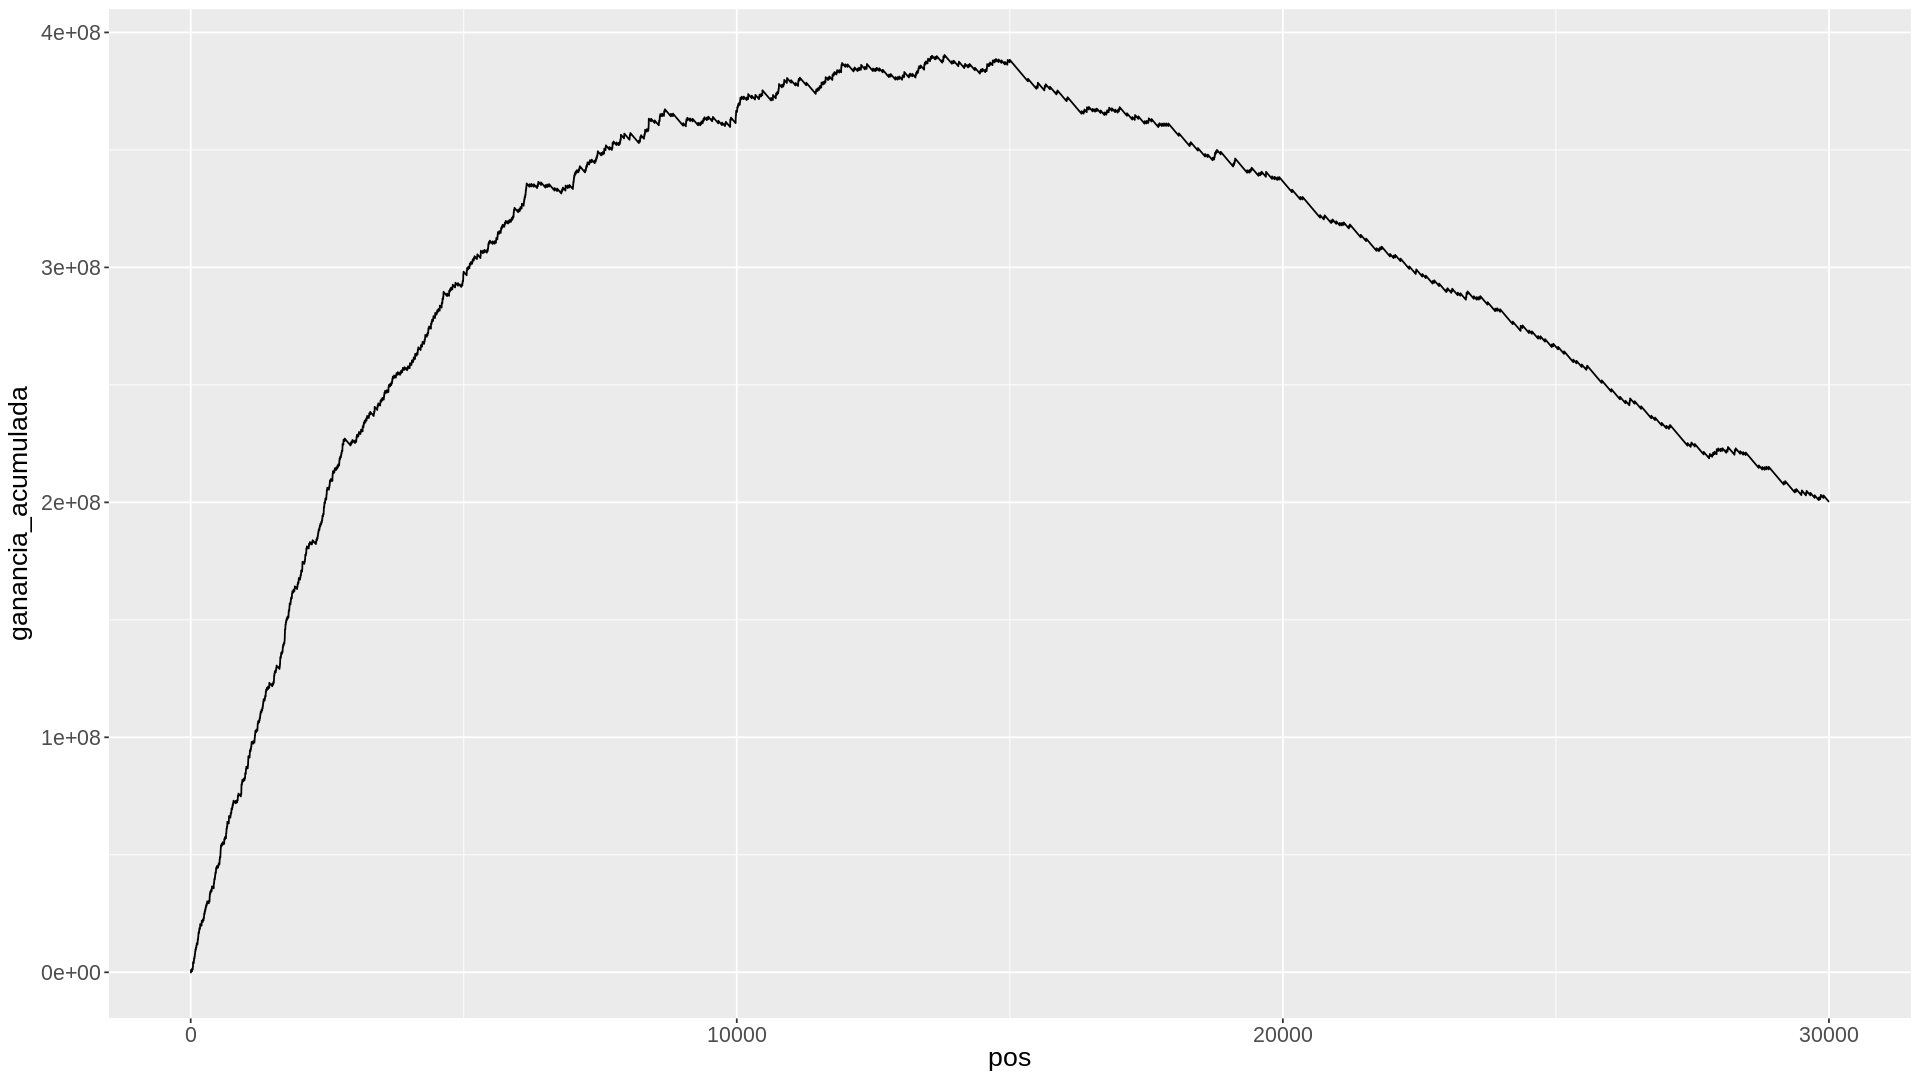

In [71]:
# observamos la curva de ganancia
gra <- ggplot(
           data= tb_prediccion[pos <= amostrar],
           aes( x= pos, y= ganancia_acumulada)
             ) + geom_line()

gra <- gra + theme(text = element_text(size = 16))

options(repr.plot.width=16, repr.plot.height=9)
print( gra )

Revisamos ganancia bajo distintos cortes

In [72]:
# inicilizo el dataset  drealidad
drealidad <- realidad_inicializar( dfuture, PARAM)

In [73]:
PARAM$cortes

[1]  4000  4500  5000  5500  6000  6500  7000  7500  8000  8500  9000  9500
[13] 10000 10500 11000 11500 12000 12500 13000 13500 14000 14500 15000 15500
[25] 16000 16500 17000 17500 18000 18500 19000

In [74]:
# genero archivos con los  "envios" mejores
# suba TODOS los archivos a Kaggle

# ordeno por probabilidad descendente
setorder(tb_prediccion, -prob)

for (envios in PARAM$cortes) {

  tb_prediccion[, Predicted := 0L] # seteo inicial a 0
  tb_prediccion[1:envios, Predicted := 1L] # marco los primeros

  res <- realidad_evaluar( drealidad, tb_prediccion)

  options(scipen = 999)
  cat( "Envios=", envios, "\t",
    " TOTAL=", res$total,
    "  Public=", res$public,
    " Private=", res$private,
    "\n",
    sep= ""
  )

}

Envios=4000	 TOTAL=257400000  Public=241816667 Private=264078571
Envios=4500	 TOTAL=279950000  Public=275000000 Private=282071429
Envios=5000	 TOTAL=298100000  Public=284533333 Private=303914286
Envios=5500	 TOTAL=310750000  Public=298558333 Private=315975000
Envios=6000	 TOTAL=324500000  Public=306258333 Private=332317857
Envios=6500	 TOTAL=334950000  Public=315425000 Private=343317857
Envios=7000	 TOTAL=334400000  Public=314141667 Private=343082143
Envios=7500	 TOTAL=348150000  Public=322758333 Private=359032143
Envios=8000	 TOTAL=355300000  Public=333483333 Private=364650000
Envios=8500	 TOTAL=362450000  Public=354383333 Private=365907143
Envios=9000	 TOTAL=360800000  Public=358691667 Private=361703571
Envios=9500	 TOTAL=363550000  Public=356400000 Private=366614286
Envios=10000	 TOTAL=366300000  Public=357133333 Private=370228571
Envios=10500	 TOTAL=374550000  Public=370516667 Private=376278571
Envios=11000	 TOTAL=379500000  Public=386008333 Private=376710714
Envios=11500	 TOTAL=37

In [75]:
write_yaml( PARAM, file="PARAM.yml")

In [76]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Wed Sep 09 04:43:46 PM 2026"

Finalmente usted deberá cargar el resultado de su corrida en la Google Sheet Colaborativa,  hoja **TareaHogar04**
<br> Siéntase libre de agregar las columnas que hagan falta a la planilla

Guardo la ganancia.

In [77]:
# guardo la tabla de ganancia por corte, para poder leerla despues

setorder(tb_prediccion, -prob)

tb_ganancia <- rbindlist(lapply(PARAM$cortes, function(envios) {

  tb_prediccion[, Predicted := 0L]
  tb_prediccion[1:envios, Predicted := 1L]

  res <- realidad_evaluar( drealidad, tb_prediccion)

  data.table(envios= envios, total= res$total,
             public= res$public, private= res$private)
}))

fwrite( tb_ganancia, file= "ganancia.txt", sep= "\t")

# tambien guardo el resumen en PARAM, que va al yml
PARAM$out$ganancia$mejor_corte_total   <- tb_ganancia[which.max(total), envios]
PARAM$out$ganancia$mejor_total         <- tb_ganancia[which.max(total), total]
PARAM$out$ganancia$mejor_corte_private <- tb_ganancia[which.max(private), envios]
PARAM$out$ganancia$mejor_private       <- tb_ganancia[which.max(private), private]

print(tb_ganancia)

    envios     total    public   private
     <num>     <num>     <num>     <num>
 1:   4000 257400000 241816667 264078571
 2:   4500 279950000 275000000 282071429
 3:   5000 298100000 284533333 303914286
 4:   5500 310750000 298558333 315975000
 5:   6000 324500000 306258333 332317857
 6:   6500 334950000 315425000 343317857
 7:   7000 334400000 314141667 343082143
 8:   7500 348150000 322758333 359032143
 9:   8000 355300000 333483333 364650000
10:   8500 362450000 354383333 365907143
11:   9000 360800000 358691667 361703571
12:   9500 363550000 356400000 366614286
13:  10000 366300000 357133333 370228571
14:  10500 374550000 370516667 376278571
15:  11000 379500000 386008333 376710714
16:  11500 375650000 383166667 372428571
17:  12000 386100000 394441667 382525000
18:  12500 384450000 402600000 376671429
19:  13000 380600000 398291667 373017857
20:  13500 387750000 413875000 376553571
21:  14000 387200000 416533333 374628571
22:  14500 384450000 409016667 373921429
23:  15000 38830

# 3.0 Ver Resultados

In [ ]:
if(!require("data.table")) install.packages("data.table")
require("data.table")
if(!require("yaml")) install.packages("yaml")
require("yaml")

kexperimento <- 4940L
carpeta_exp <- paste0("/content/buckets/b1/exp/exp", kexperimento)

if (!dir.exists(carpeta_exp)) {
  stop("No existe ", carpeta_exp,
       "\nCorriste las celdas de drive.mount y del ln -s en runtime Python 3?")
}

In [ ]:
# ============================================================
# LECTURA DE RESULTADOS  (correr despues de todo lo anterior)
# ============================================================

require("data.table")
require("yaml")

kexperimento <- 4940L   # <-- ajustar si cambiaste el numero

carpeta_HT  <- paste0("/content/buckets/b1/exp/HT",  kexperimento)
carpeta_exp <- paste0("/content/buckets/b1/exp/exp", kexperimento)

# ------------------------------------------------------------
# 1. Hiperparametros ganadores
# ------------------------------------------------------------
PARAM_leido <- read_yaml(file.path(carpeta_exp, "PARAM.yml"))

cat("=== MEJORES HIPERPARAMETROS ===\n")
print(unlist(PARAM_leido$out$lgbm$mejores_hiperparametros))
cat("\nAUC:", PARAM_leido$out$lgbm$y, "\n\n")

# ------------------------------------------------------------
# 2. Evolucion de la BO
# ------------------------------------------------------------
tb_bo <- fread(file.path(carpeta_HT, "BO_log.txt"))
setorder(tb_bo, -y)

# BO_log.txt guarda los valores SIN transformar
destrafo <- function(x) ifelse(x <= -2.9, 0, 10^x)
for (hp in intersect(c("lambda_l1","lambda_l2","min_gain_to_split"),
                     colnames(tb_bo))) {
  tb_bo[[hp]] <- destrafo(tb_bo[[hp]])
}

hps <- intersect(
  c("learning_rate","feature_fraction","num_leaves","min_data_in_leaf",
    "lambda_l1","lambda_l2","min_gain_to_split","num_iterations"),
  colnames(tb_bo))

cat("=== BAYESIAN OPTIMIZATION ===\n")
cat("Iteraciones:", nrow(tb_bo),
    "| AUC min:", round(min(tb_bo$y),5),
    " max:", round(max(tb_bo$y),5),
    " sd:", round(sd(tb_bo$y),5), "\n\n")

cat("--- Top 10 ---\n")
print(tb_bo[1:min(10,nrow(tb_bo)), c(hps,"y"), with=FALSE])

cat("\n--- Correlacion Spearman con AUC ---\n")
print(tb_bo[, lapply(.SD, function(v) round(cor(v, y, method="spearman"),3)),
            .SDcols= hps])

# ------------------------------------------------------------
# 3. Ganancia
# ------------------------------------------------------------
tb_gan <- fread(file.path(carpeta_exp, "ganancia.txt"))

options(scipen= 999)
cat("\n=== GANANCIA POR CORTE ===\n")
print(tb_gan)

cat("\nMejor corte (total):  ", tb_gan[which.max(total), envios],
    " -> ", tb_gan[which.max(total), total], "\n")
cat("Mejor corte (private):", tb_gan[which.max(private), envios],
    " -> ", tb_gan[which.max(private), private], "\n")

# ------------------------------------------------------------
# 4. Importancia de variables
# ------------------------------------------------------------
tb_impo <- fread(file.path(carpeta_exp, "impo.txt"))
cat("\n=== TOP 20 VARIABLES ===\n")
print(tb_impo[1:20])